# Membrane biophysics -- the neuron as an RC circuit
### a lipid bilayer is a capacitor, ion gradients are batteries, channels are resistors

A cell membrane is a ~3 nm lipid bilayer between salty water, and electrically it is
pure E&M:
- a **capacitor** (thin low-dielectric sheet), specific capacitance ~1 uF/cm^2;
- a set of **batteries** -- each ion's concentration gradient sets a **Nernst**
  voltage $E=\tfrac{RT}{zF}\ln\tfrac{C_\text{out}}{C_\text{in}}$ ($K^+\!\approx-95$ mV,
  $Na^+\!\approx+60$ mV);
- a **resistor** (leaky ion channels) giving the RC time constant $\tau=R_mC_m$.

Together (Goldman) they set the resting potential ~ -70 mV, and the same
$\tau=RC$ from `dgs.spice` is how fast a neuron responds. This is the bridge from your
E&M work to biology -- and to microfluidics / medical physics. Uses
`dgs/membrane_biophysics.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import membrane_biophysics as mb
print(f"RT/F at body temp = {8.314*310/96485*1e3:.1f} mV; bilayer C = {mb.specific_capacitance()*1e2:.2f} uF/cm^2")

RT/F at body temp = 26.7 mV; bilayer C = 0.85 uF/cm^2


## 1. Ion gradients as batteries -- the Nernst potential

Each ion sits across the membrane at different inside/outside concentrations. The
**Nernst potential** is the voltage at which diffusion (down the gradient) and drift
(down the electric field) cancel. Potassium ($K^+$, high inside) wants to leave, so
its equilibrium is strongly negative; sodium ($Na^+$, high outside) is positive.

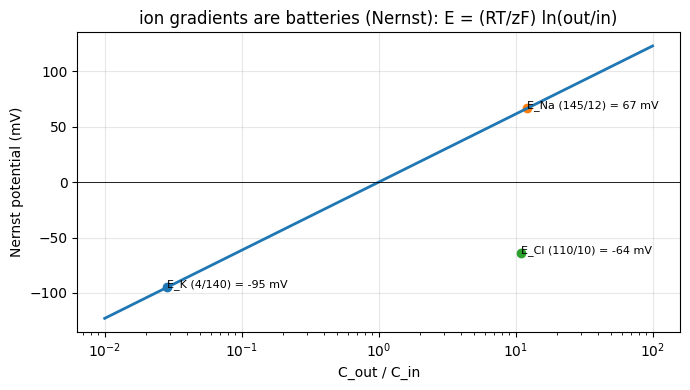

In [2]:
ratio = np.logspace(-2, 2, 200)
plt.figure(figsize=(7,4))
plt.plot(ratio, mb.nernst_potential(ratio, 1.0, +1)*1e3, lw=2)
for name, (co_, ci, z) in {"E_K (4/140)": (4,140,1), "E_Na (145/12)": (145,12,1),
                           "E_Cl (110/10)": (110,10,-1)}.items():
    E = mb.nernst_potential(co_, ci, z)*1e3
    plt.scatter([co_/ci], [E]); plt.annotate(f"{name} = {E:.0f} mV", (co_/ci, E), fontsize=8)
plt.axhline(0, color="k", lw=0.6); plt.xscale("log")
plt.xlabel("C_out / C_in"); plt.ylabel("Nernst potential (mV)")
plt.title("ion gradients are batteries (Nernst): E = (RT/zF) ln(out/in)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The resting potential -- Goldman, and the seed of the spike

The cell is permeable to several ions at once. The **Goldman-Hodgkin-Katz** equation
weights each Nernst battery by its permeability. At rest $K^+$ dominates, so the cell
sits near $E_K$ (~ -70 mV). Open $Na^+$ channels (raise $P_{Na}$) and the resting
point swings toward $E_{Na}$ -- **depolarization**, the start of an action potential.

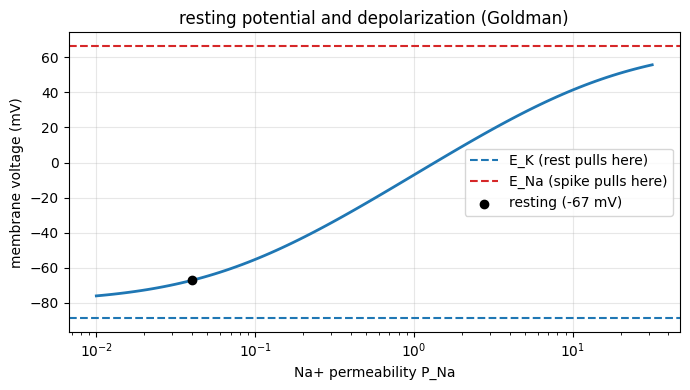

In [3]:
base = {"K":1.0,"Na":0.04,"Cl":0.45}; Co={"K":5,"Na":145,"Cl":110}; Ci={"K":140,"Na":12,"Cl":10}
P_Na = np.logspace(-2, 1.5, 100)
V = [mb.goldman_potential({**base,"Na":p}, Co, Ci)*1e3 for p in P_Na]
plt.figure(figsize=(7,4))
plt.plot(P_Na, V, lw=2)
plt.axhline(mb.nernst_potential(5,140,1)*1e3, ls="--", color="C0", label="E_K (rest pulls here)")
plt.axhline(mb.nernst_potential(145,12,1)*1e3, ls="--", color="C3", label="E_Na (spike pulls here)")
plt.scatter([0.04], [mb.goldman_potential(base,Co,Ci)*1e3], color="k", zorder=5, label="resting (-67 mV)")
plt.xscale("log"); plt.xlabel("Na+ permeability P_Na"); plt.ylabel("membrane voltage (mV)")
plt.title("resting potential and depolarization (Goldman)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The bilayer is a capacitor

The membrane is a parallel-plate capacitor: two conducting salt solutions separated
by a ~2-3 nm low-dielectric lipid core. The specific capacitance $C/A=\varepsilon_0
\varepsilon_r/d$ comes out ~1 uF/cm^2 almost regardless of cell -- a biological
constant -- which is why a cell's total capacitance just tracks its membrane area.

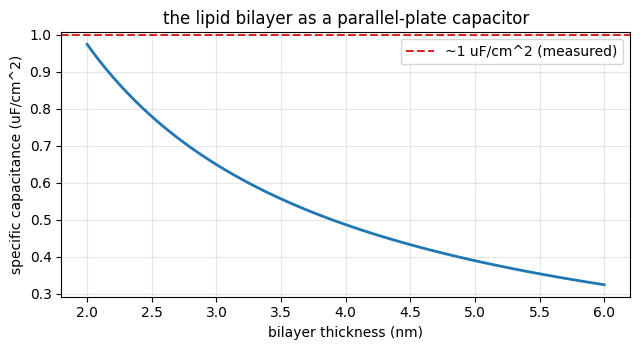

a 30 um cell (area ~ 2.8e-9 m^2): C = 24 pF


In [4]:
d = np.linspace(2e-9, 6e-9, 100)
plt.figure(figsize=(6.5,3.6))
plt.plot(d*1e9, mb.specific_capacitance(d)*1e2, lw=2)      # F/m^2 -> uF/cm^2 (*100)
plt.axhline(1.0, ls="--", color="C3", label="~1 uF/cm^2 (measured)")
plt.xlabel("bilayer thickness (nm)"); plt.ylabel("specific capacitance (uF/cm^2)")
plt.title("the lipid bilayer as a parallel-plate capacitor"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"a 30 um cell (area ~ 2.8e-9 m^2): C = {mb.membrane_capacitance(2.8e-9)*1e12:.0f} pF")

## 4. The RC clock -- how fast a neuron responds

Resistor (channels) + capacitor (bilayer) = an **RC circuit** with time constant
$\tau=R_mC_m$ (~1-20 ms). Inject a step current and the voltage charges along the same
exponential as `dgs.spice`'s RC: 63% of the way in one $\tau$. That time constant sets
how fast neurons integrate and how quickly signals can fire.

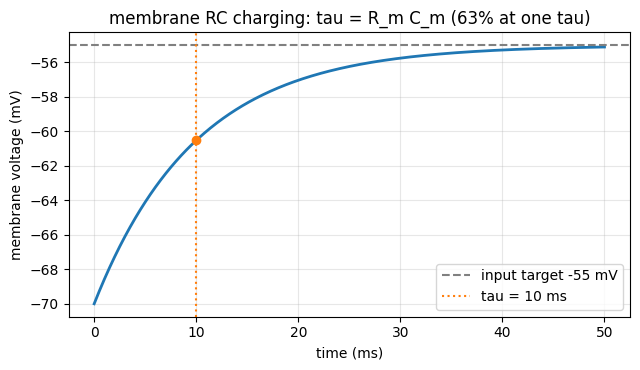

In [5]:
tau = mb.membrane_time_constant(1e8, 100e-12)            # 100 MOhm * 100 pF = 10 ms
t = np.linspace(0, 5*tau, 400)
V = mb.membrane_charging(t, V_final=-0.055, tau=tau, V0=-0.070)*1e3
plt.figure(figsize=(6.5,3.8))
plt.plot(t*1e3, V, lw=2)
plt.axhline(-55, ls="--", color="gray", label="input target -55 mV")
plt.axvline(tau*1e3, ls=":", color="C1", label=f"tau = {tau*1e3:.0f} ms")
plt.scatter([tau*1e3], [(-70 + 0.632*(-55-(-70)))], color="C1", zorder=5)  # 63% point
plt.xlabel("time (ms)"); plt.ylabel("membrane voltage (mV)")
plt.title("membrane RC charging: tau = R_m C_m (63% at one tau)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaway

1. **Nernst:** each ion gradient is a battery, $E=(RT/zF)\ln(C_\text{out}/C_\text{in})$
   -- $K^+\approx-95$, $Na^+\approx+60$ mV.
2. **Goldman:** the permeability-weighted sum gives the resting potential ~ -70 mV;
   opening $Na^+$ channels depolarizes it (the action-potential trigger).
3. **Capacitor:** the bilayer is ~1 uF/cm^2; **RC:** $\tau=R_mC_m$ ~ ms sets the speed.

A neuron is electrostatics + a thermodynamic battery + an RC circuit -- the same
capacitor and $\tau=RC$ from your circuits work, now in a cell. This is where E&M
meets biology, microfluidics, and medical physics. Civilian education.